<a href="https://colab.research.google.com/github/FinancialWisdomAI/FinancialWisdomSimulator/blob/main/Financial_Wisdom_Monte_Carlo_Simulator_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Financial Wisdom Monte Carlo Simulator

What is your financial goal? Retire at 62
What is your goal amount ($)? 600000
How many years until you need the money? 20
Initial investment amount ($): 100000
Monthly contribution ($): 200

Portfolio Choices
1 - S&P 500 Index Fund
2 - 60/40 Stock-Bond Portfolio
3 - Conservative Portfolio
Choose portfolio (1-3): 1

Risk Tolerance
1 - Low
2 - Moderate
3 - High
Choose risk tolerance (1-3): 2

Do you currently maintain an emergency fund? (yes/no): y
Do you currently have high-interest debt? (yes/no): n

Number of Monte Carlo simulations (e.g., 10000): 10000

 Financial Wisdom Simulation Results
Goal: Retire at 62
Portfolio: S&P 500 Index Fund

Mean Final Value: $1,110,802.44
Median Final Value: $848,786.61
Standard Deviation: $942,553.97

Probability of reaching $600,000.00: 67.36%

Simulation Complete.
P[X > $600,000] = 67.36%
P[X > $750,000] = 56.18%
P[X > $900,000] = 46.62%


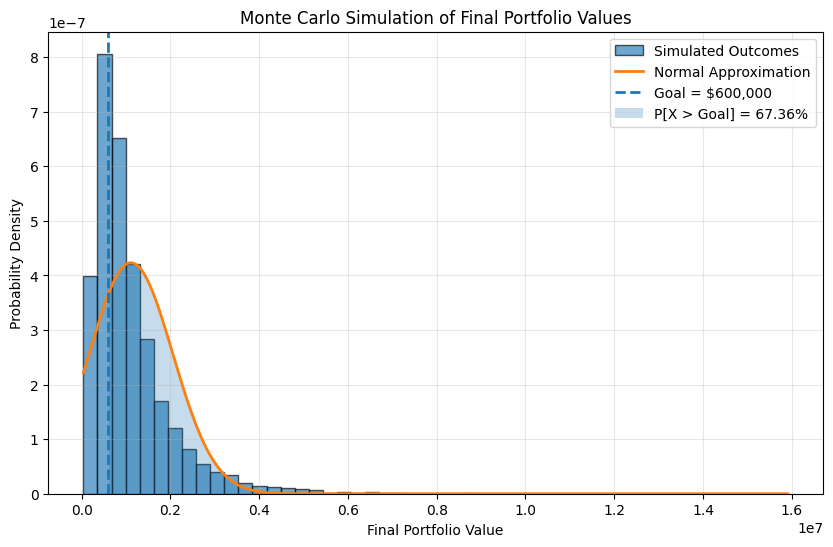


 Financial Wisdom Behavioral Analysis

• Your current plan has a reasonable probability of success. Financial Wisdom encourages periodic review to determine whether contributions or goals should be adjusted.

• Your plan shows a strong foundation because you reported having an emergency fund and no high-interest debt.

 Financial Wisdom Score
Responsibility : 5/5
Humility       : 5/5
Modesty        : 5/5
Patience       : 5/5
Self-Control   : 5/5
--------------------------------------
Total Score    : 25/25

Overall Assessment:
Strong Financial Wisdom Profile


In [4]:
# ==========================================
# Financial Wisdom Monte Carlo Simulator
# Version 1.0
# Single Cell Version
# ==========================================

import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

# ==========================================
# Utility Functions
# ==========================================

def get_money(prompt):
    while True:
        try:
            amount = float(
                input(prompt)
                .replace('$', '')
                .replace(',', '')
                .strip()
            )
            return amount
        except ValueError:
            print("Please enter a valid dollar amount.")
            print("Examples: 1000, 1,000, $1,000")


def get_integer(prompt):
    while True:
        try:
            value = int(
                input(prompt)
                .replace('$', '')
                .replace(',', '')
                .strip()
            )
            return value
        except ValueError:
            print("Please enter a whole number.")
            print("Examples: 10000 or 10,000")


# ==========================================
# Get Yes/No Response
# ==========================================

def get_yes_no(prompt):

    while True:

        response = input(prompt).strip().upper()

        if response in ["YES", "Y"]:
            return "Yes"

        elif response in ["NO", "N"]:
            return "No"

        else:
            print("Please answer Yes or No.")
            print("Examples: yes, y, no, n")

# ==========================================
# Financial Wisdom Response Library
# Version 1.1
# ==========================================

response_library = {
    "no_emergency_fund": {
        "category": "Responsibility",
        "principle": "Financial Wisdom encourages preparation before risk-taking.",
        "message": (
            "Your plan does not currently include an emergency fund. "
            "Financial Wisdom encourages establishing an emergency reserve "
            "before assuming substantial investment risk."
        )
    },

    "high_interest_debt": {
        "category": "Responsibility",
        "principle": "Costly debt works against long-term progress.",
        "message": (
            "Your plan includes high-interest debt. Financial Wisdom encourages "
            "addressing costly debt obligations before assuming additional investment risk."
        )
    },

    "aggressive_short_horizon": {
        "category": "Patience",
        "principle": "Wealth is usually built gradually, not suddenly.",
        "message": (
            "Your plan uses an aggressive stock portfolio over a short time horizon. "
            "Financial Wisdom recognizes that market declines can occur at inconvenient times."
        )
    },

    "low_probability": {
        "category": "Modesty",
        "principle": "Wise goals should be challenging but attainable.",
        "message": (
            "The probability of reaching your stated goal is currently low. "
            "Consider increasing contributions, extending the time horizon, or revising the goal."
        )
    },

    "risk_mismatch": {
        "category": "Humility",
        "principle": "Humility recognizes that market outcomes are uncertain.",
        "message": (
            "Your portfolio choice appears more aggressive than your stated risk tolerance. "
            "Financial Wisdom encourages aligning investment choices with your ability to endure uncertainty."
        )
    },

    "no_monthly_contribution": {
        "category": "Self-Control",
        "principle": "Repeated actions shape future outcomes.",
        "message": (
            "Your plan does not include regular monthly contributions. "
            "Financial Wisdom encourages consistent saving because habits compound over time."
        )
    },

    "high_probability_success": {
    "category": "Encouragement",
    "principle": "Discipline and patience often lead to favorable outcomes.",
    "message": (
        "Your current plan has a relatively high probability of reaching your goal. "
        "Financial Wisdom encourages continued discipline, periodic review, and patience."
       )
    },

    "moderate_probability_success": {
    "category": "Encouragement",
    "principle": (
        "Periodic review can strengthen long-term plans."
        ),
    "message": (
        "Your current plan has a reasonable probability "
        "of success. Financial Wisdom encourages "
        "periodic review to determine whether "
        "contributions or goals should be adjusted."
         )
    },

    "strong_foundation": {
    "category": "Responsibility",
    "principle": "A sound financial foundation supports long-term success.",
    "message": (
        "Your plan shows a strong foundation because you reported having an emergency fund "
        "and no high-interest debt."
       )
    }
}

# ==========================================
# User Input Layer
# ==========================================

print("======================================")
print(" Financial Wisdom Monte Carlo Simulator")
print("======================================\n")

goal_name = input("What is your financial goal? ")

goal_amount = get_money(
    "What is your goal amount ($)? ")

years = get_integer(
    "How many years until you need the money? ")

initial_balance = get_money(
    "Initial investment amount ($): ")

monthly_contribution = get_money(
    "Monthly contribution ($): ")

# ==========================================
# Financial Wisdom Validation Checks
# ==========================================

if goal_amount <= 0:
    print("\nERROR:")
    print("Goal amount must be greater than zero.")

if initial_balance < 0:
    print("\nERROR:")
    print("Initial investment cannot be negative.")

if monthly_contribution < 0:
    print("\nERROR:")
    print("Monthly contribution cannot be negative.")

if goal_amount <= initial_balance:

    print("\nFINANCIAL WISDOM OBSERVATION:")
    print("Your initial investment already meets "
          "or exceeds your stated goal.")

    print("You may wish to:")
    print("1 - Continue the simulation.")
    print("2 - Enter a new goal amount.")

    choice = get_integer("Choose 1 or 2: ")

    if choice == 2:
        goal_amount = get_money(
            "Enter a new goal amount ($): ")

if monthly_contribution > goal_amount:

    print("\nWARNING:")
    print("Your monthly contribution exceeds "
          "your stated goal.")

    print("Please verify that both values "
          "were entered correctly.")

print("\nPortfolio Choices")
print("1 - S&P 500 Index Fund")
print("2 - 60/40 Stock-Bond Portfolio")
print("3 - Conservative Portfolio")

portfolio_choice = get_integer(
    "Choose portfolio (1-3): ")

print("\nRisk Tolerance")
print("1 - Low")
print("2 - Moderate")
print("3 - High")

risk_tolerance = get_integer(
    "Choose risk tolerance (1-3): ")

emergency_fund = get_yes_no(
    "\nDo you currently maintain an emergency fund? (yes/no): ")

high_interest_debt = get_yes_no(
    "Do you currently have high-interest debt? (yes/no): ")

num_simulations = get_integer(
    "\nNumber of Monte Carlo simulations (e.g., 10000): ")


# ==========================================
# Store User Plan
# ==========================================

user_plan = {
    "goal_name": goal_name,
    "goal_amount": goal_amount,
    "years": years,
    "initial_balance": initial_balance,
    "monthly_contribution": monthly_contribution,
    "portfolio_choice": portfolio_choice,
    "risk_tolerance": risk_tolerance,
    "emergency_fund": emergency_fund,
    "high_interest_debt": high_interest_debt,
    "num_simulations": num_simulations
}


# ==========================================
# Portfolio Model Layer
# ==========================================

if portfolio_choice == 1:
    portfolio_name = "S&P 500 Index Fund"
    mean_return = 0.1185
    std_return = 0.194

elif portfolio_choice == 2:
    portfolio_name = "60/40 Stock-Bond Portfolio"
    mean_return = 0.08
    std_return = 0.12

elif portfolio_choice == 3:
    portfolio_name = "Conservative Portfolio"
    mean_return = 0.05
    std_return = 0.06

else:
    raise ValueError(
        "Invalid portfolio choice. Choose 1, 2, or 3.")


# ==========================================
# Monte Carlo Engine
# ==========================================

final_values = []

for sim in range(num_simulations):

    balance = initial_balance

    for year in range(years):

        annual_return = np.random.normal(
            mean_return, std_return)

        # Prevent annual return less than -99%
        annual_return = max(annual_return, -0.99)

        monthly_return = (
            (1 + annual_return)**(1/12) - 1
        )

        if abs(monthly_return) < 1e-12:
            yearly_contribution_value = (
                monthly_contribution * 12
            )
        else:
            yearly_contribution_value = (
                monthly_contribution *
                (((1 + monthly_return)**12 - 1)
                 / monthly_return)
            )

        balance = (
            balance * (1 + annual_return)
            + yearly_contribution_value
        )

    final_values.append(balance)

final_values = np.array(final_values)

# ==========================================
# Layer 4: Results and Visualization
# ==========================================

goal = goal_amount

mean_final = np.mean(final_values)

median_final = np.median(final_values)

std_final = np.std(final_values)

prob_success = np.mean(final_values > goal)

# ==========================================
# Display Results
# ==========================================

print("\n======================================")
print(" Financial Wisdom Simulation Results")
print("======================================")

print(f"Goal: {goal_name}")
print(f"Portfolio: {portfolio_name}")

print(f"\nMean Final Value: "
      f"${mean_final:,.2f}")

print(f"Median Final Value: "
      f"${median_final:,.2f}")

print(f"Standard Deviation: "
      f"${std_final:,.2f}")

print(f"\nProbability of reaching "
      f"${goal_amount:,.2f}: "
      f"{prob_success:.2%}")

print("\nSimulation Complete.")

# ==========================================
# Optional: Specific Probability Questions
# ==========================================

for target in [
        goal_amount,
        1.25 * goal_amount,
        1.50 * goal_amount]:

    probability = np.mean(final_values > target)

    print(
        f"P[X > ${target:,.0f}] = "
        f"{probability:.2%}")

# ==========================================
# Layer 4: Results and Visualization
# ==========================================

goal = user_plan["goal_amount"]

mean_final = np.mean(final_values)
median_final = np.median(final_values)
std_final = np.std(final_values)

prob_success = np.mean(final_values > goal)

# ==========================================
# Histogram with Normal Approximation
# ==========================================

plt.figure(figsize=(10, 6))

count, bins, ignored = plt.hist(
    final_values,
    bins=50,
    density=True,
    edgecolor="black",
    alpha=0.65,
    label="Simulated Outcomes"
)

x = np.linspace(min(final_values), max(final_values), 500)
normal_curve = norm.pdf(x, mean_final, std_final)

plt.plot(
    x,
    normal_curve,
    linewidth=2,
    label="Normal Approximation"
)

plt.axvline(
    goal,
    linestyle="--",
    linewidth=2,
    label=f"Goal = ${goal:,.0f}"
)

plt.fill_between(
    x,
    normal_curve,
    where=(x > goal),
    alpha=0.25,
    label=f"P[X > Goal] = {prob_success:.2%}"
)

plt.xlabel("Final Portfolio Value")
plt.ylabel("Probability Density")
plt.title("Monte Carlo Simulation of Final Portfolio Values")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==========================================
# Layer 5: Expanded Financial Wisdom Behavioral Engine
# Version 1.2
# ==========================================

behavior_observations = []


def add_observation(key):
    if key in response_library:
        behavior_observations.append(response_library[key])
    else:
        print(f"Warning: Response key '{key}' not found.")


# -----------------------------
# Responsibility Checks
# -----------------------------

if emergency_fund == "No":
    add_observation("no_emergency_fund")

if high_interest_debt == "Yes":
    add_observation("high_interest_debt")

if monthly_contribution <= 0:
    add_observation("no_monthly_contribution")


# -----------------------------
# Humility Checks
# -----------------------------

if portfolio_choice == 1 and risk_tolerance == 1:
    add_observation("risk_mismatch")

if portfolio_choice == 1 and years <= 5:
    add_observation("aggressive_short_horizon")


# -----------------------------
# Modesty Checks
# -----------------------------

if prob_success < 0.10:
    add_observation("very_low_probability")

elif prob_success < 0.40:
    add_observation("low_probability")

if mean_final < 0.75 * goal_amount:
    add_observation("mean_below_goal")


# -----------------------------
# Patience Checks
# -----------------------------

if years <= 5:
    add_observation("short_time_horizon")

if years < 10 and goal_amount > 10 * monthly_contribution * 12:
    add_observation("goal_large_relative_to_contribution")


# -----------------------------
# Self-Control Checks
# -----------------------------

if monthly_contribution > 0 and monthly_contribution < 100:
    add_observation("small_monthly_contribution")

if high_interest_debt == "Yes" and portfolio_choice == 1:
    add_observation("aggressive_investing_with_debt")


# -----------------------------
# Stewardship and Encouragement Checks
# -----------------------------

if goal_amount <= initial_balance:
    add_observation("goal_already_met")

if prob_success >= 0.75:
    add_observation("high_probability_success")
elif prob_success >= 0.50:
    add_observation("moderate_probability_success")

if emergency_fund == "Yes" and high_interest_debt == "No":
    add_observation("strong_foundation")


# ==========================================
# Display Behavioral Analysis
# ==========================================

print("\n======================================")
print(" Financial Wisdom Behavioral Analysis")
print("======================================")

if len(behavior_observations) == 0:
    print("No major Financial Wisdom concerns were detected.")
else:
    for item in behavior_observations:
        print(f"\n• {item['message']}")

behavior_report = "\n".join(
    item["message"] for item in behavior_observations
)


# ==========================================
# Layer 6: Financial Wisdom Scoring System
# Version 1.1
# ==========================================

responsibility_score = 5
humility_score = 5
modesty_score = 5
patience_score = 5
self_control_score = 5

# Responsibility
if emergency_fund == "No":
    responsibility_score -= 2

if high_interest_debt == "Yes":
    responsibility_score -= 2

if monthly_contribution <= 0:
    responsibility_score -= 1

# Humility
if portfolio_choice == 1 and risk_tolerance == 1:
    humility_score -= 2

if portfolio_choice == 1 and years <= 5:
    humility_score -= 1

# Modesty
if prob_success < 0.10:
    modesty_score -= 3
elif prob_success < 0.40:
    modesty_score -= 1

if mean_final < 0.75 * goal_amount:
    modesty_score -= 1

# Patience
if years <= 5:
    patience_score -= 2

if years < 10 and goal_amount > 10 * monthly_contribution * 12:
    patience_score -= 1

# Self-Control
if monthly_contribution <= 0:
    self_control_score -= 2

if monthly_contribution > 0 and monthly_contribution < 100:
    self_control_score -= 1

if high_interest_debt == "Yes" and portfolio_choice == 1:
    self_control_score -= 1

# Prevent negative scores
responsibility_score = max(0, responsibility_score)
humility_score = max(0, humility_score)
modesty_score = max(0, modesty_score)
patience_score = max(0, patience_score)
self_control_score = max(0, self_control_score)

fw_score = (
    responsibility_score +
    humility_score +
    modesty_score +
    patience_score +
    self_control_score
)

# ==========================================
# Display Scores
# ==========================================

print("\n======================================")
print(" Financial Wisdom Score")
print("======================================")

print(f"Responsibility : {responsibility_score}/5")
print(f"Humility       : {humility_score}/5")
print(f"Modesty        : {modesty_score}/5")
print(f"Patience       : {patience_score}/5")
print(f"Self-Control   : {self_control_score}/5")

print("--------------------------------------")
print(f"Total Score    : {fw_score}/25")

# Overall Assessment

print("\nOverall Assessment:")

if fw_score >= 23:
    print("Strong Financial Wisdom Profile")

elif fw_score >= 18:
    print("Sound Financial Plan")

elif fw_score >= 11:
    print("Several areas should be reviewed")

else:
    print("Plan requires significant review")

# ==========================================
# Store Financial Wisdom Scores
# ==========================================

financial_wisdom_profile = {
    "Responsibility": responsibility_score,
    "Humility": humility_score,
    "Modesty": modesty_score,
    "Patience": patience_score,
    "Self-Control": self_control_score,
    "Total Score": fw_score
}

simulation_results = {
    "mean_final": mean_final,
    "median_final": median_final,
    "std_final": std_final,
    "goal_amount": goal_amount,
    "prob_success": prob_success,
    "portfolio_name": portfolio_name
}